1. Install Libraries

In [ ]:
!pip -q install "pennylane==0.36.0" "autoray==0.6.11" "numpy==1.26.4" scikit-learn matplotlib pillow tqdm

In [ ]:
import os
os.kill(os.getpid(), 9)

In [ ]:
import numpy as np
import pennylane as qml
import torch
import sklearn
import matplotlib

print("NumPy:", np.__version__)
print("PennyLane:", qml.__version__)
print("Torch:", torch.__version__)
print("sklearn:", sklearn.__version__)
print("matplotlib:", matplotlib.__version__)

NumPy: 1.26.4
PennyLane: 0.36.0
Torch: 2.10.0+cu128
sklearn: 1.6.1
matplotlib: 3.10.0


2. Imports and Version Check

In [ ]:
import os
import json
import math
import copy
import random
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
)

import pennylane as qml
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

print("Torch:", torch.__version__)
print("PennyLane:", qml.__version__)
print("CUDA available:", torch.cuda.is_available())

Torch: 2.10.0+cu128
PennyLane: 0.36.0
CUDA available: True


3. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


4. Seed and Device Setup

In [ ]:
SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


5. Project Paths and Folder Verification

In [ ]:
project_root_candidates = [
    Path("/content/drive/MyDrive/Project Test 3"),
    Path("/content/drive/MyDrive/Project test 3"),
    Path("/content/drive/MyDrive/Project Test3"),
    Path("/content/drive/MyDrive/Project test3"),
]

project_root = None
for p in project_root_candidates:
    if p.exists():
        project_root = p
        break

if project_root is None:
    raise FileNotFoundError("Project Test 3 folder not found in MyDrive.")

patches_dir = project_root / "DFU" / "Patches"
normal_dir = patches_dir / "Normal(Healthy skin)"

abnormal_candidates = [
    patches_dir / "Abnormal(Ucer)",
    patches_dir / "Abnormal(Ulcer)",
    patches_dir / "Abnormal (Ucer)",
    patches_dir / "Abnormal (Ulcer)",
]

abnormal_dir = None
for p in abnormal_candidates:
    if p.exists():
        abnormal_dir = p
        break

if not patches_dir.exists():
    raise FileNotFoundError(f"Patches folder not found: {patches_dir}")

if not normal_dir.exists():
    raise FileNotFoundError(f"Normal folder not found: {normal_dir}")

if abnormal_dir is None:
    raise FileNotFoundError("Could not find abnormal folder. Expected Abnormal(Ucer) or Abnormal(Ulcer).")

output_dir = project_root / "outputs_model_3_final"
output_dir.mkdir(parents=True, exist_ok=True)

print("Project root:", project_root)
print("Patches dir:", patches_dir)
print("Normal dir exists:", normal_dir.exists(), "->", normal_dir)
print("Abnormal dir exists:", abnormal_dir.exists(), "->", abnormal_dir)
print("Output dir:", output_dir)

Project root: /content/drive/MyDrive/Project Test 3
Patches dir: /content/drive/MyDrive/Project Test 3/DFU/Patches
Normal dir exists: True -> /content/drive/MyDrive/Project Test 3/DFU/Patches/Normal(Healthy skin)
Abnormal dir exists: True -> /content/drive/MyDrive/Project Test 3/DFU/Patches/Abnormal(Ulcer)
Output dir: /content/drive/MyDrive/Project Test 3/outputs_model_3_final


6. Configuration

In [ ]:
CONFIG = {
    "image_size": 224,
    "batch_size": 16,
    "num_workers": 2,
    "train_size": 0.70,
    "val_size": 0.15,
    "test_size": 0.15,

    "backbone": "resnet18",
    "pretrained": True,

    "freeze_backbone_stage1": True,
    "unfreeze_layer4_stage2": True,

    "feature_dim": 4,
    "n_qubits": 4,
    "n_q_layers": 2,
    "dropout": 0.30,

    "lr_stage1": 1e-4,
    "lr_stage2": 5e-5,
    "weight_decay": 1e-4,

    "epochs_stage1": 10,
    "epochs_stage2": 10,
    "early_stopping_patience": 5,
    "grad_clip": 1.0,

    "decision_threshold": 0.5,
    "use_weighted_sampler": True,

    "noise_prob": 0.01,
    "amp_damp_prob": 0.01,

    "save_dir": str(output_dir),
}
CONFIG

{'image_size': 224,
 'batch_size': 16,
 'num_workers': 2,
 'train_size': 0.7,
 'val_size': 0.15,
 'test_size': 0.15,
 'backbone': 'resnet18',
 'pretrained': True,
 'freeze_backbone_stage1': True,
 'unfreeze_layer4_stage2': True,
 'feature_dim': 4,
 'n_qubits': 4,
 'n_q_layers': 2,
 'dropout': 0.3,
 'lr_stage1': 0.0001,
 'lr_stage2': 5e-05,
 'weight_decay': 0.0001,
 'epochs_stage1': 10,
 'epochs_stage2': 10,
 'early_stopping_patience': 5,
 'grad_clip': 1.0,
 'decision_threshold': 0.5,
 'use_weighted_sampler': True,
 'noise_prob': 0.01,
 'amp_damp_prob': 0.01,
 'save_dir': '/content/drive/MyDrive/Project Test 3/outputs_model_3_final'}

7. Build Dataset File List

In [ ]:
def list_images(folder: Path):
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    return sorted([str(p) for p in folder.iterdir() if p.is_file() and p.suffix.lower() in exts])

normal_images = list_images(normal_dir)
abnormal_images = list_images(abnormal_dir)

print("Normal images:", len(normal_images))
print("Abnormal images:", len(abnormal_images))

if len(normal_images) == 0 or len(abnormal_images) == 0:
    raise ValueError("No images found in one or both dataset folders.")

samples = []
for img in normal_images:
    samples.append((img, 0))
for img in abnormal_images:
    samples.append((img, 1))

random.shuffle(samples)

image_paths = [x[0] for x in samples]
labels = [x[1] for x in samples]

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths,
    labels,
    test_size=(1 - CONFIG["train_size"]),
    random_state=SEED,
    stratify=labels,
)

relative_test_size = CONFIG["test_size"] / (CONFIG["val_size"] + CONFIG["test_size"])

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=relative_test_size,
    random_state=SEED,
    stratify=temp_labels,
)

print("Train:", len(train_paths))
print("Val:", len(val_paths))
print("Test:", len(test_paths))

Normal images: 543
Abnormal images: 512
Train: 738
Val: 158
Test: 159


8. Transforms and Dataset Class

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.10, contrast=0.10, saturation=0.10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

class DFUDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        label = int(self.labels[idx])

        if self.transform:
            image = self.transform(image)

        return image, label

train_dataset = DFUDataset(train_paths, train_labels, transform=train_transform)
val_dataset = DFUDataset(val_paths, val_labels, transform=eval_transform)
test_dataset = DFUDataset(test_paths, test_labels, transform=eval_transform)

9. DataLoaders

In [ ]:
if CONFIG["use_weighted_sampler"]:
    class_counts = np.bincount(train_labels)
    sample_weights = [1.0 / class_counts[label] for label in train_labels]
    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=CONFIG["batch_size"],
        sampler=sampler,
        num_workers=CONFIG["num_workers"],
        pin_memory=True
    )
else:
    train_loader = DataLoader(
        train_dataset,
        batch_size=CONFIG["batch_size"],
        shuffle=True,
        num_workers=CONFIG["num_workers"],
        pin_memory=True
    )

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 47
Val batches: 10
Test batches: 10


10. Visual Check of Training Images

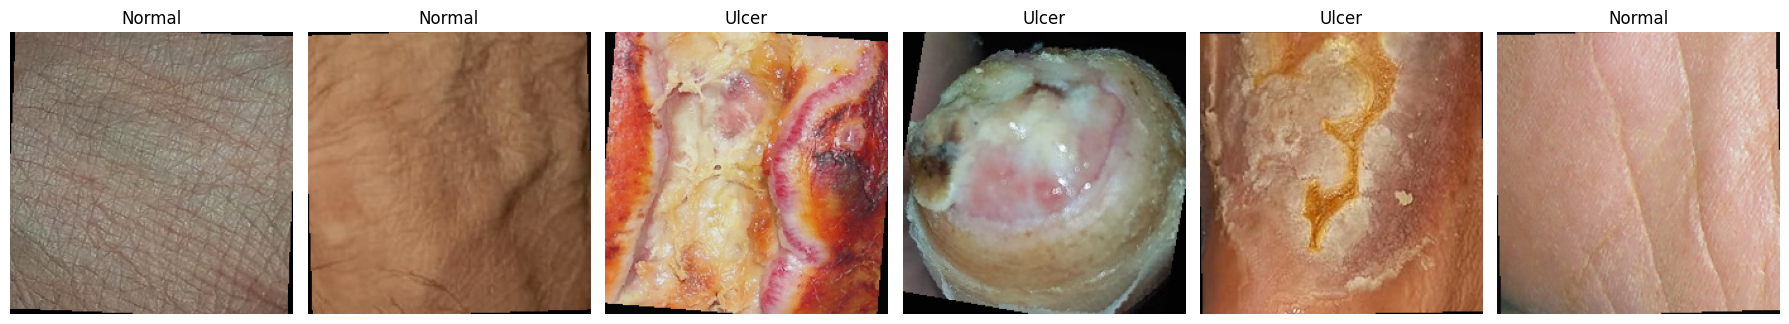

In [ ]:
def show_batch(dataset, n=6):
    fig, axes = plt.subplots(1, n, figsize=(18, 4))
    for i in range(n):
        img, label = dataset[i]
        img = img.permute(1, 2, 0).numpy()
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img = np.clip(img, 0, 1)
        axes[i].imshow(img)
        axes[i].set_title("Ulcer" if label == 1 else "Normal")
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

show_batch(train_dataset, n=6)

11. Metrics Utilities

In [ ]:
def compute_binary_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
    }

    try:
        metrics["roc_auc"] = float(roc_auc_score(y_true, y_prob))
    except Exception:
        metrics["roc_auc"] = 0.0

    cm = confusion_matrix(y_true, y_pred)
    metrics["confusion_matrix"] = cm.tolist()

    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        metrics["specificity"] = float(tn / max(tn + fp, 1))
        metrics["sensitivity"] = float(tp / max(tp + fn, 1))
    else:
        metrics["specificity"] = 0.0
        metrics["sensitivity"] = 0.0

    return metrics

12. Quantum Layer Builder

In [ ]:
def make_quantum_layer(
    n_qubits=4,
    n_q_layers=2,
    use_noise=False,
    noise_prob=0.01,
    amp_damp_prob=0.01,
):
    backend = "default.mixed" if use_noise else "default.qubit"
    dev = qml.device(backend, wires=n_qubits)

    @qml.qnode(dev, interface="torch", diff_method="best")
    def qnode(inputs, weights):
        qml.AngleEmbedding(inputs, wires=range(n_qubits), rotation="Y")

        for layer in range(n_q_layers):
            for i in range(n_qubits):
                qml.Rot(
                    weights[layer, i, 0],
                    weights[layer, i, 1],
                    weights[layer, i, 2],
                    wires=i
                )

                if use_noise:
                    qml.DepolarizingChannel(noise_prob, wires=i)
                    qml.AmplitudeDamping(amp_damp_prob, wires=i)

            for i in range(n_qubits):
                qml.CNOT(wires=[i, (i + 1) % n_qubits])
                if use_noise:
                    qml.DepolarizingChannel(noise_prob, wires=(i + 1) % n_qubits)

        return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

    weight_shapes = {"weights": (n_q_layers, n_qubits, 3)}
    qlayer = qml.qnn.TorchLayer(qnode, weight_shapes)
    return qlayer

13. Hybrid Model Definition

In [ ]:
class HybridDFUModel(nn.Module):
    def __init__(self, config, use_noise=False):
        super().__init__()
        self.config = config
        self.use_noise = use_noise

        if config["backbone"] == "resnet18":
            weights = models.ResNet18_Weights.DEFAULT if config["pretrained"] else None
            backbone = models.resnet18(weights=weights)
            in_features = backbone.fc.in_features
            backbone.fc = nn.Identity()
        else:
            raise ValueError("Currently only resnet18 is enabled for stability.")

        self.backbone = backbone

        self.feature_projector = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(config["dropout"]),
            nn.Linear(256, config["feature_dim"]),
            nn.Tanh()
        )

        self.quantum = make_quantum_layer(
            n_qubits=config["n_qubits"],
            n_q_layers=config["n_q_layers"],
            use_noise=use_noise,
            noise_prob=config["noise_prob"],
            amp_damp_prob=config["amp_damp_prob"],
        )

        self.classifier = nn.Sequential(
            nn.Linear(config["n_qubits"], 16),
            nn.ReLU(),
            nn.Dropout(config["dropout"]),
            nn.Linear(16, 1)
        )

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_layer4_only(self):
        for p in self.backbone.parameters():
            p.requires_grad = False
        for p in self.backbone.layer4.parameters():
            p.requires_grad = True

    def forward(self, x):
        features = self.backbone(x)
        features = self.feature_projector(features)

        q_outputs = []
        for i in range(features.shape[0]):
            q_outputs.append(self.quantum(features[i]))

        q_outputs = torch.stack(q_outputs, dim=0)
        logits = self.classifier(q_outputs)
        return logits

14. Training and Prediction Functions

In [ ]:
def run_epoch(model, loader, criterion, optimizer=None, train=True):
    model.train(train)

    losses = []
    y_true = []
    y_prob = []

    progress = tqdm(loader, leave=False)

    for images, labels in progress:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE).float().unsqueeze(1)

        with torch.set_grad_enabled(train):
            logits = model(images)
            loss = criterion(logits, labels)
            probs = torch.sigmoid(logits)

            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=CONFIG["grad_clip"])
                optimizer.step()

        losses.append(loss.item())
        y_true.extend(labels.detach().cpu().numpy().flatten().astype(int).tolist())
        y_prob.extend(probs.detach().cpu().numpy().flatten().tolist())

        progress.set_description(("Train" if train else "Eval") + f" Loss: {loss.item():.4f}")

    avg_loss = float(np.mean(losses))
    metrics = compute_binary_metrics(
        np.array(y_true),
        np.array(y_prob),
        threshold=CONFIG["decision_threshold"]
    )
    return avg_loss, metrics

@torch.no_grad()
def predict_probs(model, loader):
    model.eval()

    y_true = []
    y_prob = []

    for images, labels in loader:
        images = images.to(DEVICE)
        logits = model(images)
        probs = torch.sigmoid(logits).detach().cpu().numpy().flatten()

        y_true.extend(labels.numpy().tolist())
        y_prob.extend(probs.tolist())

    return np.array(y_true), np.array(y_prob)

15. Full Training Function With Two-Stage Fine-Tuning

In [ ]:
def train_full_model(model_name="ideal_hybrid", use_noise=False):
    print("\n" + "=" * 80)
    print(f"STARTING TRAINING: {model_name}")
    print("=" * 80)

    model = HybridDFUModel(CONFIG, use_noise=use_noise).to(DEVICE)

    train_class_counts = np.bincount(train_labels)
    neg_count = train_class_counts[0]
    pos_count = train_class_counts[1]
    pos_weight = torch.tensor([neg_count / max(pos_count, 1)], dtype=torch.float32).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "train_f1": [],
        "val_f1": [],
        "train_auc": [],
        "val_auc": [],
        "stage": [],
    }

    best_state = None
    best_val_loss = float("inf")
    best_epoch = -1
    global_epoch = 0
    patience_counter = 0

    def save_best():
        torch.save(
            {
                "state_dict": best_state,
                "best_val_loss": best_val_loss,
                "best_epoch": best_epoch,
                "config": CONFIG,
                "use_noise": use_noise,
                "model_name": model_name,
            },
            Path(CONFIG["save_dir"]) / f"best_{model_name}.pt"
        )

    # Stage 1
    model.freeze_backbone()
    optimizer = optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=CONFIG["lr_stage1"],
        weight_decay=CONFIG["weight_decay"]
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=1
    )

    print("\nStage 1: frozen backbone training")
    for epoch in range(1, CONFIG["epochs_stage1"] + 1):
        global_epoch += 1

        train_loss, train_metrics = run_epoch(model, train_loader, criterion, optimizer=optimizer, train=True)
        val_loss, val_metrics = run_epoch(model, val_loader, criterion, optimizer=None, train=False)
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_metrics["accuracy"])
        history["val_acc"].append(val_metrics["accuracy"])
        history["train_f1"].append(train_metrics["f1"])
        history["val_f1"].append(val_metrics["f1"])
        history["train_auc"].append(train_metrics["roc_auc"])
        history["val_auc"].append(val_metrics["roc_auc"])
        history["stage"].append("stage1")

        print(
            f"Epoch {global_epoch:02d} | "
            f"Train Loss {train_loss:.4f} | Val Loss {val_loss:.4f} | "
            f"Val F1 {val_metrics['f1']:.4f} | Val AUC {val_metrics['roc_auc']:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = global_epoch
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
            save_best()
        else:
            patience_counter += 1

        if patience_counter >= CONFIG["early_stopping_patience"]:
            print("Early stopping triggered in Stage 1.")
            break

    # Stage 2
    if CONFIG["unfreeze_layer4_stage2"]:
        model.unfreeze_layer4_only()
        optimizer = optim.AdamW(
            [p for p in model.parameters() if p.requires_grad],
            lr=CONFIG["lr_stage2"],
            weight_decay=CONFIG["weight_decay"]
        )
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=0.5,
            patience=1
        )

        print("\nStage 2: fine-tuning last backbone block")
        for epoch in range(1, CONFIG["epochs_stage2"] + 1):
            global_epoch += 1

            train_loss, train_metrics = run_epoch(model, train_loader, criterion, optimizer=optimizer, train=True)
            val_loss, val_metrics = run_epoch(model, val_loader, criterion, optimizer=None, train=False)
            scheduler.step(val_loss)

            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)
            history["train_acc"].append(train_metrics["accuracy"])
            history["val_acc"].append(val_metrics["accuracy"])
            history["train_f1"].append(train_metrics["f1"])
            history["val_f1"].append(val_metrics["f1"])
            history["train_auc"].append(train_metrics["roc_auc"])
            history["val_auc"].append(val_metrics["roc_auc"])
            history["stage"].append("stage2")

            print(
                f"Epoch {global_epoch:02d} | "
                f"Train Loss {train_loss:.4f} | Val Loss {val_loss:.4f} | "
                f"Val F1 {val_metrics['f1']:.4f} | Val AUC {val_metrics['roc_auc']:.4f}"
            )

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_epoch = global_epoch
                best_state = copy.deepcopy(model.state_dict())
                patience_counter = 0
                save_best()
            else:
                patience_counter += 1

            if patience_counter >= CONFIG["early_stopping_patience"]:
                print("Early stopping triggered in Stage 2.")
                break

    print(f"\nBest epoch: {best_epoch}, Best val loss: {best_val_loss:.4f}")

    checkpoint = torch.load(Path(CONFIG["save_dir"]) / f"best_{model_name}.pt", map_location=DEVICE)
    model.load_state_dict(checkpoint["state_dict"])

    y_true, y_prob = predict_probs(model, test_loader)
    test_metrics = compute_binary_metrics(y_true, y_prob, threshold=CONFIG["decision_threshold"])

    with open(Path(CONFIG["save_dir"]) / f"test_metrics_{model_name}.json", "w") as f:
        json.dump(test_metrics, f, indent=2)

    with open(Path(CONFIG["save_dir"]) / f"history_{model_name}.json", "w") as f:
        json.dump(history, f, indent=2)

    return model, history, y_true, y_prob, test_metrics

16. Train Ideal Hybrid Model

In [ ]:
ideal_model, ideal_history, ideal_y_true, ideal_y_prob, ideal_test_metrics = train_full_model(
    model_name="ideal_hybrid",
    use_noise=False
)

print("\nIdeal Hybrid Test Metrics")
print(json.dumps(ideal_test_metrics, indent=2))


STARTING TRAINING: ideal_hybrid
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 244MB/s]



Stage 1: frozen backbone training


  0%|          | 0/47 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

...

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch 19 | Train Loss 0.6663 | Val Loss 0.6597 | Val F1 0.0000 | Val AUC 0.9995


  0%|          | 0/47 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch 20 | Train Loss 0.6722 | Val Loss 0.6579 | Val F1 0.0000 | Val AUC 0.9997

Best epoch: 20, Best val loss: 0.6579

Ideal Hybrid Test Metrics
{
  "accuracy": 0.5157232704402516,
  "precision": 0.0,
  "recall": 0.0,
  "f1": 0.0,
  "roc_auc": 1.0,
  "confusion_matrix": [
    [
      82,
      0
    ],
    [
      77,
      0
    ]
  ],
  "specificity": 1.0,
  "sensitivity": 0.0
}


17. Train Noise-Aware Hybrid Model

In [ ]:
noisy_model, noisy_history, noisy_y_true, noisy_y_prob, noisy_test_metrics = train_full_model(
    model_name="noisy_hybrid",
    use_noise=True
)

print("\nNoise-Aware Hybrid Test Metrics")
print(json.dumps(noisy_test_metrics, indent=2))


STARTING TRAINING: noisy_hybrid

Stage 1: frozen backbone training


  0%|          | 0/47 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch 01 | Train Loss 0.7132 | Val Loss 0.7068 | Val F1 0.8415 | Val AUC 0.9885


  0%|          | 0/47 [00:00<?, ?it/s]

...

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch 19 | Train Loss 0.6305 | Val Loss 0.6265 | Val F1 0.9872 | Val AUC 1.0000


  0%|          | 0/47 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch 20 | Train Loss 0.6258 | Val Loss 0.6241 | Val F1 0.9935 | Val AUC 0.9998

Best epoch: 20, Best val loss: 0.6241

Noise-Aware Hybrid Test Metrics
{
  "accuracy": 0.9937106918238994,
  "precision": 1.0,
  "recall": 0.987012987012987,
  "f1": 0.9934640522875817,
  "roc_auc": 0.9998416217928413,
  "confusion_matrix": [
    [
      82,
      0
    ],
    [
      1,
      76
    ]
  ],
  "specificity": 1.0,
  "sensitivity": 0.987012987012987
}


18. Save Comparison Summary

In [ ]:
comparison = {
    "ideal_hybrid": ideal_test_metrics,
    "noisy_hybrid": noisy_test_metrics
}

with open(Path(CONFIG["save_dir"]) / "comparison_metrics.json", "w") as f:
    json.dump(comparison, f, indent=2)

print(json.dumps(comparison, indent=2))

{
  "ideal_hybrid": {
    "accuracy": 0.5157232704402516,
    "precision": 0.0,
    "recall": 0.0,
    "f1": 0.0,
    "roc_auc": 1.0,
    "confusion_matrix": [
      [
        82,
        0
      ],
      [
        77,
        0
      ]
    ],
    "specificity": 1.0,
    "sensitivity": 0.0
  },
  "noisy_hybrid": {
    "accuracy": 0.9937106918238994,
    "precision": 1.0,
    "recall": 0.987012987012987,
    "f1": 0.9934640522875817,
    "roc_auc": 0.9998416217928413,
    "confusion_matrix": [
      [
        82,
        0
      ],
      [
        1,
        76
      ]
    ],
    "specificity": 1.0,
    "sensitivity": 0.987012987012987
  }
}


19. Plot Training Curves

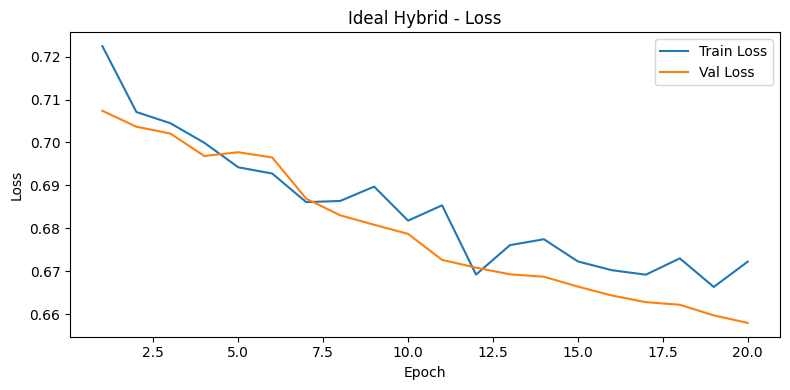

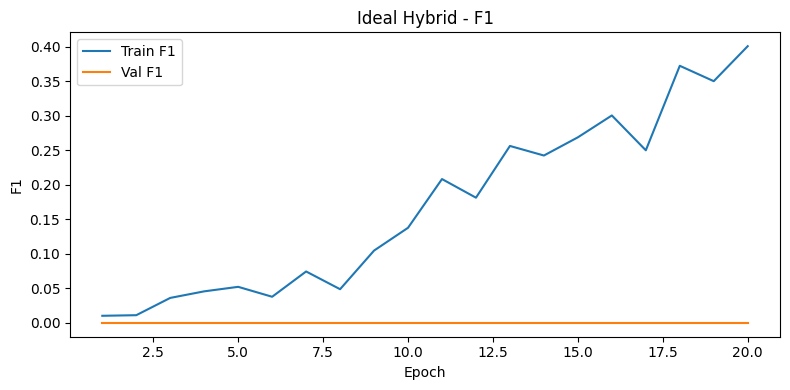

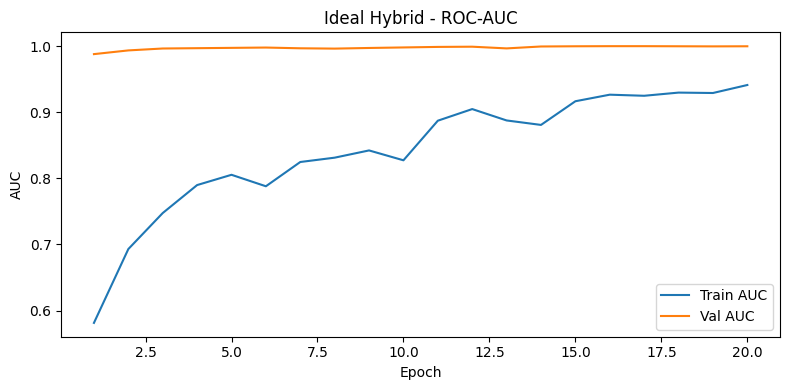

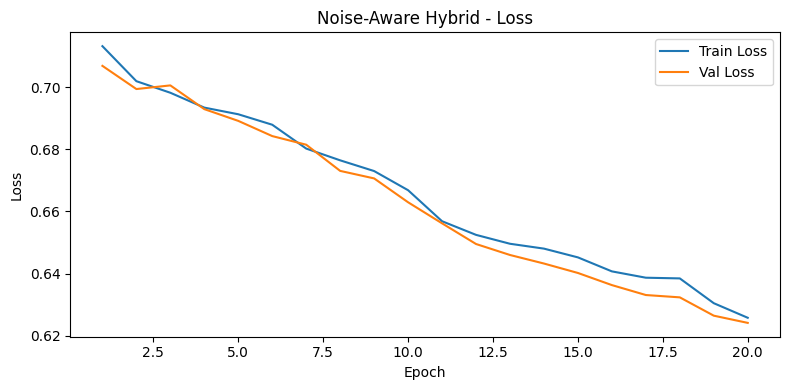

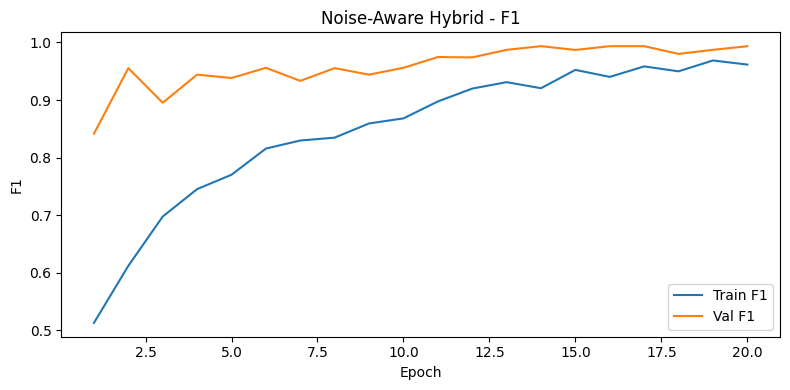

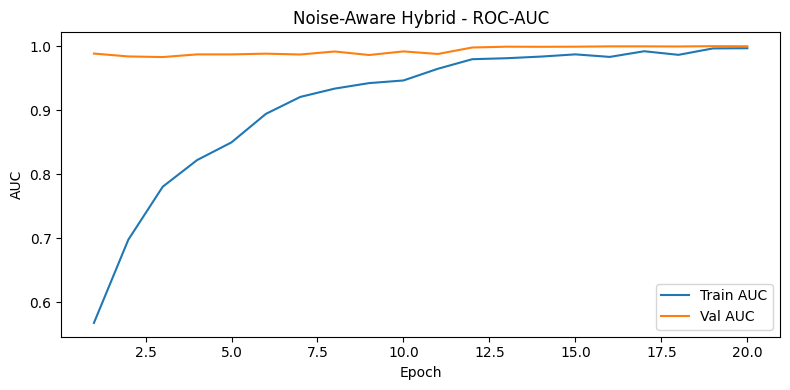

In [ ]:
def plot_history(history, title_prefix):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} - Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history["train_f1"], label="Train F1")
    plt.plot(epochs, history["val_f1"], label="Val F1")
    plt.xlabel("Epoch")
    plt.ylabel("F1")
    plt.title(f"{title_prefix} - F1")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history["train_auc"], label="Train AUC")
    plt.plot(epochs, history["val_auc"], label="Val AUC")
    plt.xlabel("Epoch")
    plt.ylabel("AUC")
    plt.title(f"{title_prefix} - ROC-AUC")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_history(ideal_history, "Ideal Hybrid")
plot_history(noisy_history, "Noise-Aware Hybrid")

20. Confusion Matrices and Reports

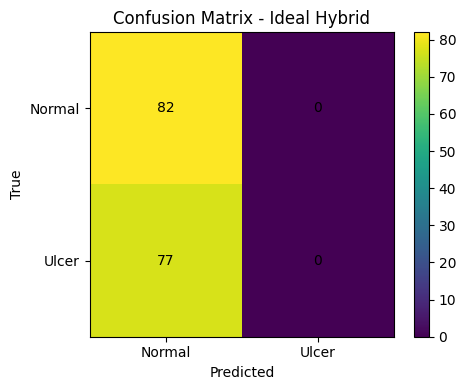

              precision    recall  f1-score   support

      Normal       0.52      1.00      0.68        82
       Ulcer       0.00      0.00      0.00        77

    accuracy                           0.52       159
   macro avg       0.26      0.50      0.34       159
weighted avg       0.27      0.52      0.35       159



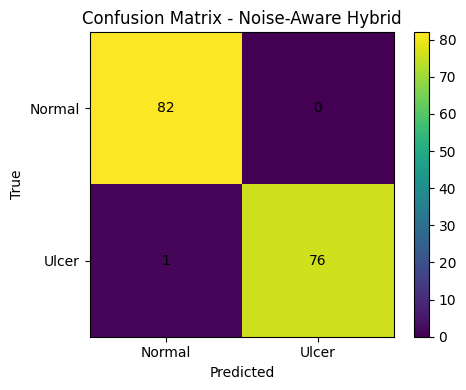

              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99        82
       Ulcer       1.00      0.99      0.99        77

    accuracy                           0.99       159
   macro avg       0.99      0.99      0.99       159
weighted avg       0.99      0.99      0.99       159



In [ ]:
def plot_confusion_and_report(y_true, y_prob, title):
    y_pred = (y_prob >= CONFIG["decision_threshold"]).astype(int)
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    plt.xticks([0, 1], ["Normal", "Ulcer"])
    plt.yticks([0, 1], ["Normal", "Ulcer"])
    plt.xlabel("Predicted")
    plt.ylabel("True")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.show()

    print(classification_report(
        y_true,
        y_pred,
        target_names=["Normal", "Ulcer"],
        zero_division=0
    ))

plot_confusion_and_report(ideal_y_true, ideal_y_prob, "Confusion Matrix - Ideal Hybrid")
plot_confusion_and_report(noisy_y_true, noisy_y_prob, "Confusion Matrix - Noise-Aware Hybrid")

21. ROC Curve Comparison

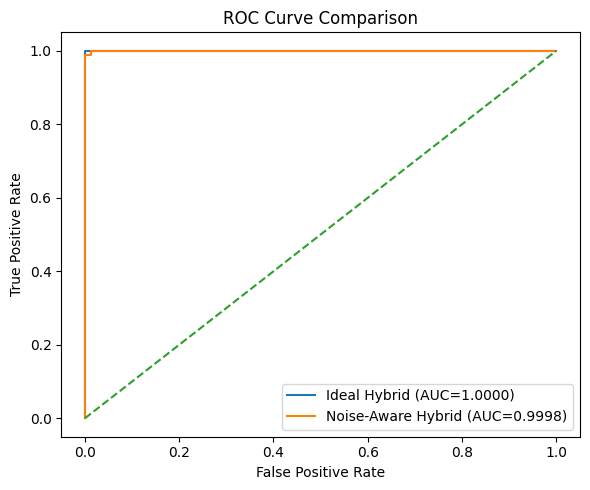

In [ ]:
def plot_roc_comparison(y_true_1, y_prob_1, y_true_2, y_prob_2):
    fpr1, tpr1, _ = roc_curve(y_true_1, y_prob_1)
    auc1 = roc_auc_score(y_true_1, y_prob_1)

    fpr2, tpr2, _ = roc_curve(y_true_2, y_prob_2)
    auc2 = roc_auc_score(y_true_2, y_prob_2)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr1, tpr1, label=f"Ideal Hybrid (AUC={auc1:.4f})")
    plt.plot(fpr2, tpr2, label=f"Noise-Aware Hybrid (AUC={auc2:.4f})")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve Comparison")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_roc_comparison(ideal_y_true, ideal_y_prob, noisy_y_true, noisy_y_prob)

22. Single Image Prediction Cell

In [ ]:
single_transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

@torch.no_grad()
def predict_single_image(image_path, model):
    model.eval()
    image = Image.open(image_path).convert("RGB")
    x = single_transform(image).unsqueeze(0).to(DEVICE)

    logits = model(x)
    prob = torch.sigmoid(logits).item()
    pred = 1 if prob >= CONFIG["decision_threshold"] else 0

    print("Image:", image_path)
    print("Predicted class:", "Ulcer" if pred == 1 else "Normal")
    print("Ulcer probability:", round(prob, 4))

# Example:
# predict_single_image(abnormal_images[0], ideal_model)
# predict_single_image(normal_images[0], noisy_model)

23. Final Output Check

In [ ]:
print("Saved files in output directory:")
for p in sorted(Path(CONFIG["save_dir"]).glob("*")):
    print("-", p.name)

Saved files in output directory:
- best_ideal_hybrid.pt
- best_noisy_hybrid.pt
- comparison_metrics.json
- history_ideal_hybrid.json
- history_noisy_hybrid.json
- test_metrics_ideal_hybrid.json
- test_metrics_noisy_hybrid.json
